# 01 - Data Understanding

This notebook loads the NASA Exoplanet Archive dataset and performs initial inspection, cleaning of raw formatting issues, and basic exploration of variables before feature engineering and modeling.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/raw/exoplanets_raw.csv", comment="#")
df.head()

,pl_name,discoverymethod,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,...,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
0,11 Com b,Radial Velocity,323.21000,0.06,-0.05,0.0,NaN,NaN,NaN,NaN,...,0.08,-0.08,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
1,11 Com b,Radial Velocity,326.03000,0.32,-0.32,0.0,NaN,NaN,NaN,NaN,...,0.10,-0.10,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
2,11 Com b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
3,11 UMi b,Radial Velocity,516.21997,3.20,-3.20,0.0,NaN,NaN,NaN,NaN,...,0.07,-0.07,0.0,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765
4,11 UMi b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765


In [ ]:
df.shape

(39954, 50)

In [ ]:
df.columns

Index(['pl_name', 'discoverymethod', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_msinie', 'pl_msinieerr1',
       'pl_msinieerr2', 'pl_msinielim', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_eqt', 'pl_eqterr1',
       'pl_eqterr2', 'pl_eqtlim', 'st_spectype', 'st_teff', 'st_tefferr1',
       'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2',
       'st_radlim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim',
       'st_lum', 'st_lumerr1', 'st_lumerr2', 'st_lumlim', 'st_logg',
       'st_loggerr1', 'st_loggerr2', 'st_logglim', 'st_age', 'st_ageerr1',
       'st_ageerr2', 'st_agelim', 'sy_dist', 'sy_disterr1', 'sy_disterr2'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39954 entries, 0 to 39953
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39954 non-null  str    
 1   discoverymethod  39954 non-null  str    
 2   pl_orbper        36595 non-null  float64
 3   pl_orbpererr1    34884 non-null  float64
 4   pl_orbpererr2    34883 non-null  float64
 5   pl_orbperlim     36595 non-null  float64
 6   pl_rade          27540 non-null  float64
 7   pl_radeerr1      26795 non-null  float64
 8   pl_radeerr2      26795 non-null  float64
 9   pl_radelim       30286 non-null  float64
 10  pl_msinie        2731 non-null   float64
 11  pl_msinieerr1    2460 non-null   float64
 12  pl_msinieerr2    2460 non-null   float64
 13  pl_msinielim     2731 non-null   float64
 14  pl_orbeccen      19019 non-null  float64
 15  pl_orbeccenerr1  3945 non-null   float64
 16  pl_orbeccenerr2  3944 non-null   float64
 17  pl_orbeccenlim   21763 

In [ ]:
df.isna().sum().sort_values(ascending=False).head(10)

pl_msinieerr1      37494
pl_msinieerr2      37494
pl_eqterr2         37246
pl_eqterr1         37246
pl_msinielim       37223
pl_msinie          37223
st_spectype        36851
pl_orbeccenerr2    36010
pl_orbeccenerr1    36009
st_lumerr2         35109
dtype: int64

In [ ]:
df.describe()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_msinie,pl_msinieerr1,...,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
count,3.659500e+04,3.488400e+04,3.488300e+04,36595.000000,27540.000000,26795.000000,26795.000000,30286.000000,2731.000000,2460.000000,...,25521.000000,25520.000000,30979.000000,9834.000000,9375.000000,9375.000000,21214.000000,39100.000000,38237.000000,38237.000000
mean,1.196132e+04,1.382946e+04,-3.259654e+03,-0.000246,5.446621,1.936948,-0.762182,-0.000132,754.363525,95.260145,...,0.099101,-0.152428,-0.000194,4.617140,2.394776,-1.958636,-0.007354,721.138011,36.958126,-38.638563
std,2.102652e+06,2.516611e+06,5.366524e+05,0.020245,71.212750,74.735067,18.890319,0.014075,1212.893344,586.842737,...,0.110765,0.138738,0.016069,3.480304,1.809221,1.338874,0.102496,834.733135,158.350847,184.599385
min,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.270000,0.000000,-1916.293000,-1.000000,0.015000,0.000000,...,0.000000,-3.510000,-1.000000,0.000000,0.000000,-18.000000,-1.000000,1.301190,0.000340,-2900.000000
25%,4.362737e+00,8.009250e-06,-2.006000e-04,0.000000,1.560000,0.158000,-0.460000,0.000000,21.606166,2.692440,...,0.033000,-0.260000,0.000000,2.100000,0.940000,-2.900000,0.000000,268.685000,1.909500,-20.190000
50%,1.030066e+01,3.824000e-05,-3.829000e-05,0.000000,2.308000,0.362309,-0.220000,0.000000,324.186600,19.069704,...,0.068274,-0.105000,0.000000,4.000000,2.000000,-1.790000,0.000000,573.000000,7.271500,-7.189000
75%,2.644435e+01,2.012000e-04,-8.041200e-06,0.000000,3.300000,0.790000,-0.120000,0.000000,890.261000,63.566000,...,0.110000,-0.057000,0.000000,6.200000,3.605000,-0.860000,0.000000,928.989000,20.856000,-1.896000
max,4.020000e+08,4.700000e+08,0.000000e+00,1.000000,4282.980000,8872.156000,0.000000,1.000000,17668.169700,24965.546500,...,2.010000,0.000000,1.000000,16.800000,26.000000,0.000000,1.000000,8980.000000,3160.000000,2700.000000


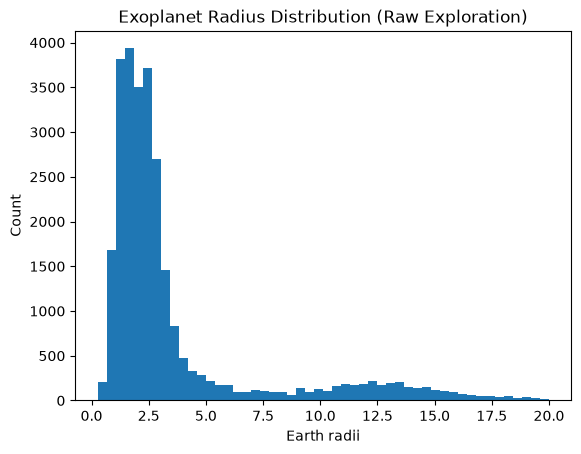

In [ ]:
df_vis = df[df["pl_rade"] < 20]

plt.hist(df_vis["pl_rade"], bins=50)
plt.title("Exoplanet Radius Distribution (Raw Exploration)")
plt.xlabel("Earth radii")
plt.ylabel("Count")
plt.show()

## Key Observations

- Dataset contains missing values across multiple stellar and planetary attributes
- Planet radius distribution is heavily right-skewed
- Majority of planets fall between 1–3 Earth radii
- Large outliers exist and will require careful handling in later phases